In [10]:
# Import necessary libraries
import os
import numpy as np
from PIL import Image, ImageChops
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Function to generate Error Level Analysis (ELA) image
def generate_ela(image_path):
    """
    Generate ELA image by comparing original with JPEG compressed version.
    """
    # Load original image
    original = Image.open(image_path)
    
    # Save a temporary JPEG at 90% quality
    temp_path = 'temp.jpg'
    original.save(temp_path, 'JPEG', quality=90)
    
    # Load the compressed version
    compressed = Image.open(temp_path)
    
    # Compute difference
    ela = ImageChops.difference(original, compressed)
    
    # Convert to grayscale if needed (though difference might already be)
    ela = ela.convert('L')
    
    # Enhance the brightness of the difference (multiply by 10 for visibility)
    ela_array = np.array(ela)
    ela_enhanced = np.clip(ela_array * 10, 0, 255).astype(np.uint8)
    ela = Image.fromarray(ela_enhanced)
    
    # Remove temporary file
    os.remove(temp_path)
    
    return ela

# Function to load limited dataset from CASIA v2
def load_data(real_dir, fake_dir, limit=300):
    """
    Load ELA features from real and fake images, limited to prevent RAM issues.
    Resize to 100x100 and flatten.
    """
    data = []
    labels = []
    
    # Valid image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif')
    
    # Load real images
    real_files = [f for f in os.listdir(real_dir) if f.lower().endswith(valid_extensions)][:limit]
    for img_file in real_files:
        img_path = os.path.join(real_dir, img_file)
        try:
            ela = generate_ela(img_path)
            ela_resized = ela.resize((100, 100))
            ela_flat = np.array(ela_resized).flatten()
            data.append(ela_flat)
            labels.append(0)  # 0 for real
        except Exception as e:
            print(f"Skipping {img_path}: {e}")
            continue
    
    # Load fake images
    fake_files = [f for f in os.listdir(fake_dir) if f.lower().endswith(valid_extensions)][:limit]
    for img_file in fake_files:
        img_path = os.path.join(fake_dir, img_file)
        try:
            ela = generate_ela(img_path)
            ela_resized = ela.resize((100, 100))
            ela_flat = np.array(ela_resized).flatten()
            data.append(ela_flat)
            labels.append(1)  # 1 for fake
        except Exception as e:
            print(f"Skipping {img_path}: {e}")
            continue
    
    return np.array(data), np.array(labels)

# Define paths (adjust these to your CASIA v2 dataset locations)
real_dir = 'CASIA2/Au'  
fake_dir = 'CASIA2/Tp'  

# Load data with strict 100-image limit to protect 8GB RAM
print("Loading data...")
data, labels = load_data(real_dir, fake_dir, limit=100)
print(f"Loaded {len(data)} images: {np.sum(labels==0)} real, {np.sum(labels==1)} fake")

# Split data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Train Random Forest model
print("Training model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
print("Evaluating...")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\n{'='*60}")
print(f"ACCURACY SCORE: {accuracy:.4f}")
print(f"{'='*60}")
print("\nCONFUSION MATRIX:")
print(conf_matrix)
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)']))
print("\nConfusion Matrix Explanation:")
print("[[True Negatives (Real correctly classified), False Positives (Real misclassified as Fake)]")
print(" [False Negatives (Fake misclassified as Real), True Positives (Fake correctly classified)]]")

Loading data...
Loaded 200 images: 100 real, 100 fake
Training model...
Evaluating...

ACCURACY SCORE: 0.9250

CONFUSION MATRIX:
[[19  2]
 [ 1 18]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real (0)       0.95      0.90      0.93        21
    Fake (1)       0.90      0.95      0.92        19

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.93        40


Confusion Matrix Explanation:
[[True Negatives (Real correctly classified), False Positives (Real misclassified as Fake)]
 [False Negatives (Fake misclassified as Real), True Positives (Fake correctly classified)]]


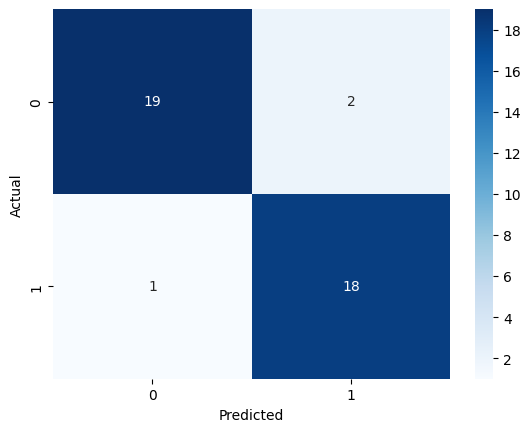

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = [[19, 2], [1, 18]]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')

In [11]:
# Save the trained model using joblib
import joblib

model_filename = 'tampering_model.pkl'
joblib.dump(model, model_filename)
print(f"Model saved to {model_filename}")

Model saved to tampering_model.pkl


In [12]:
# Inference function for tampering detection
import joblib
import numpy as np
from evidence_security import get_ela_image

def predict_tampering(image_path):
    """
    Load the trained model, process an image into ELA array, and predict tampering.

    Args:
        image_path (str): Path to the image file

    Returns:
        tuple: (label, confidence) where label is 'Authentic' or 'Tampered', confidence is float
    """
    # Load the saved model
    model = joblib.load('tampering_model.pkl')

    # Generate ELA image
    ela_image = get_ela_image(image_path)

    # Resize and flatten ELA image (same as training)
    ela_resized = ela_image.resize((100, 100))
    ela_flat = np.array(ela_resized).flatten().reshape(1, -1)

    # Predict
    prediction = model.predict(ela_flat)[0]
    probabilities = model.predict_proba(ela_flat)[0]

    # Get label and confidence
    label = 'Authentic' if prediction == 0 else 'Tampered'
    confidence = probabilities[prediction]

    return label, confidence

# Example usage
# label, confidence = predict_tampering('path/to/image.jpg')
# print(f"Prediction: {label} (Confidence: {confidence:.2f})")